In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import cv2
import glob
from google.colab.patches import cv2_imshow

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy
from torch.utils.data import Dataset, DataLoader

In [4]:
import numpy as np
import pandas as pd
import os, math, sys
import glob, itertools
import argparse, random

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torchvision.models import vgg19
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
from torchvision.utils import save_image,make_grid
import plotly
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm_notebook as tqdm
from sklearn.model_selection import train_test_split

random.seed(42)
import warnings
warnings.filterwarnings("ignore")

In [5]:
class ImageDataset(Dataset):
    def __init__(self, root, transforms_=None, img_size=128, mask_size=64, mode="train"):
        self.transform = transforms.Compose(transforms_)
        self.img_size = img_size
        self.mask_size = mask_size
        self.mode = mode
        self.files = sorted(glob.glob("%s/*.png" % root))
        self.files = self.files[:6000] if mode == "train" else self.files[6000:]

    def apply_random_mask(self, img):
        """Randomly masks image"""
        y1, x1 = np.random.randint(0, self.img_size - self.mask_size, 2)
        y2, x2 = y1 + self.mask_size, x1 + self.mask_size
        masked_part = img[:, y1:y2, x1:x2]
        masked_img = img.clone()
        masked_img[:, y1:y2, x1:x2] = 1
        return img, masked_img

    

    def __getitem__(self, index):

        img = Image.open(self.files[index % len(self.files)]).convert('RGB')
        img = self.transform(img)
        img, masked_img= self.apply_random_mask(img)
        return img, masked_img

    def __len__(self):
        return len(self.files)

In [ ]:
nef = 64                #  of encoder filters in first conv layer
ngf = 64               #  of gen filters in first conv layer
ndf = 64               #  of discrim filters in first conv layer
nc = 3              # of channels in input
nBottleneck=100

In [6]:
transforms_ = [
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5)),
]
dataloader = DataLoader(
    ImageDataset("/content/drive/MyDrive/Unlabeled", transforms_=transforms_),
    batch_size=32,
    shuffle=True,
    num_workers=1,
)
test_dataloader = DataLoader(
    ImageDataset("/content/drive/MyDrive/Unlabeled", transforms_=transforms_, mode="val"),
    batch_size=8,
    shuffle=True,
    num_workers=1,
)

In [ ]:
len(dataloader)

188

In [7]:
next(iter(dataloader))[1].shape

torch.Size([32, 3, 128, 128])

In [8]:
test=ImageDataset("/content/drive/MyDrive/Unlabeled", transforms_=transforms_, mode="val")
train= ImageDataset("/content/drive/MyDrive/Unlabeled", transforms_=transforms_)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


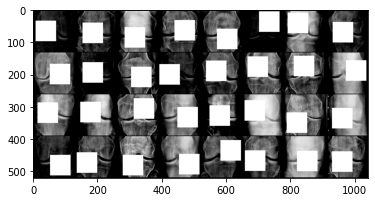

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


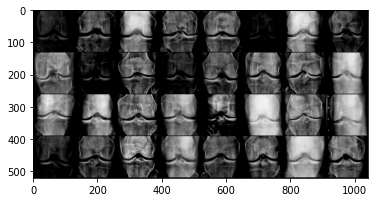

In [ ]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated
# Get a batch of training data
ground_truth,masked_img, masked_part= next(iter(dataloader))

# Make a grid from batch
out = torchvision.utils.make_grid(masked_img)
gt = torchvision.utils.make_grid(ground_truth)
imshow(out)
imshow(gt)

In [9]:
class conv_block(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()

        self.conv1 = nn.Conv2d(in_c, out_c, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_c)

        self.conv2 = nn.Conv2d(out_c, out_c, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_c)

        self.relu = nn.ReLU()

    def forward(self, inputs):
        x = self.conv1(inputs)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)

        return x

class encoder_block(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()

        self.conv = conv_block(in_c, out_c)
        self.pool = nn.MaxPool2d((2, 2))

    def forward(self, inputs):
        x = self.conv(inputs)
        p = self.pool(x)

        return x, p


In [10]:
class decoder_block(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()

        self.up = nn.ConvTranspose2d(in_c, out_c, kernel_size=2, stride=2, padding=0)
        self.conv = conv_block(out_c+out_c, out_c)

    def forward(self, inputs, skip):
        x = self.up(inputs)
        x = torch.cat([x, skip], axis=1)
        x = self.conv(x)

        return x

In [11]:
class build_unet(nn.Module):
    def __init__(self):
        super().__init__()

        """ Encoder """
        self.e1 = encoder_block(3, 64)
        self.e2 = encoder_block(64, 128)
        self.e3 = encoder_block(128, 256)
        self.e4 = encoder_block(256, 512)

        """ Bottleneck """
        self.b = conv_block(512, 1024)

        """ Decoder """
        self.d1 = decoder_block(1024, 512)
        self.d2 = decoder_block(512, 256)
        self.d3 = decoder_block(256, 128)
        self.d4 = decoder_block(128, 64)

        """ Classifier """
        self.outputs = nn.Conv2d(64, 3, kernel_size=1, padding=0)

    def forward(self, inputs):
        """ Encoder """
        s1, p1 = self.e1(inputs)
        s2, p2 = self.e2(p1)
        s3, p3 = self.e3(p2)
        s4, p4 = self.e4(p3)

        """ Bottleneck """
        b = self.b(p4)

        """ Decoder """
        d1 = self.d1(b, s4)
        d2 = self.d2(d1, s3)
        d3 = self.d3(d2, s2)
        d4 = self.d4(d3, s1)

        """ Classifier """
        outputs = self.outputs(d4)

        return outputs

In [12]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using {device} device')

Using cuda device


In [13]:
model=build_unet().to(device)

In [ ]:
class Generator(nn.Module):
    def __init__(self,channels=3):
        super(Generator, self).__init__()


        self.encoder=nn.Sequential(nn.Conv2d(nc, nef, 4, 2, 1), nn.LeakyReLU(0.2),
                                   #state size: (nef) x 64 x 64
                                  nn.Conv2d(nef, nef, 4, 2, 1), nn.BatchNorm2d(nef), nn.LeakyReLU(0.2, True),
                                                      #(nef) x 32 x 32
                                  nn.Conv2d(nef, nef * 2, 4, 2, 1), nn.BatchNorm2d(nef * 2), nn.LeakyReLU(0.2, True),
                                  #(nef*2) x 16 x 16
                                  nn.Conv2d(nef * 2, nef * 4, 4, 2, 1),nn.BatchNorm2d(nef * 4),nn.LeakyReLU(0.2, True),
                                  #(nef*4) x 8 x 8
                                  nn.Conv2d(nef * 4, nef * 8, 4, 2, 1),nn.BatchNorm2d(nef * 8),nn.LeakyReLU(0.2, True),
                                  #(nef*8) x 4 x 4
                                  nn.Conv2d(nef * 8, nBottleneck, 4, 4))
                                  #(nBottleneck) x 1 x 1
        self.decoder=nn.Sequential(nn.ConvTranspose2d(nBottleneck, ngf * 8, 4, 4),nn.BatchNorm2d(ngf * 8),nn.ReLU(True),
                                   #(ngf*8) x 4 x 4
                                   nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2,1),nn.BatchNorm2d(ngf * 4), nn.ReLU(True),
                                   #(ngf*4) x 8 x 8
                                   nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1),nn.BatchNorm2d(ngf * 2), nn.ReLU(True),
                                  #(ngf*2) x 16 x 16
                                   nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1),nn.BatchNorm2d(ngf), nn.ReLU(True),
                                   #(ngf) x 32 x 32,
                                   nn.ConvTranspose2d(ngf, nc, 4, 2, 1),nn.BatchNorm2d(nc), nn.ReLU(True),
                                   nn.ConvTranspose2d(nc, nc, 4, 2, 1), nn.Tanh(),
                                   )
                                   #(nc) x 128 x 128

    def forward(self, x):
            x = self.encoder(x)
            x = self.decoder(x)
            return x



In [14]:
def dice_coeff(pred, target):
    smooth = 1.
    num = pred.size(0)
    m1 = pred.view(num, -1).float()  # Flatten
    m2 = target.view(num, -1).float()  # Flatten
    intersection = (m1 * m2).sum().float()

    return (2. * intersection + smooth) / (m1.sum() + m2.sum() + smooth)

In [ ]:
%%time
for name, param in inpaintingmodel.named_parameters():
    print('name: ', name)
    print(type(param))
    print('param.shape: ', param.shape)
    print('param.requires_grad: ', param.requires_grad)
    print('=====')

name:  encoder.0.weight
<class 'torch.nn.parameter.Parameter'>
param.shape:  torch.Size([64, 3, 4, 4])
param.requires_grad:  True
=====
name:  encoder.0.bias
<class 'torch.nn.parameter.Parameter'>
param.shape:  torch.Size([64])
param.requires_grad:  True
=====
name:  encoder.2.weight
<class 'torch.nn.parameter.Parameter'>
param.shape:  torch.Size([64, 64, 4, 4])
param.requires_grad:  True
=====
name:  encoder.2.bias
<class 'torch.nn.parameter.Parameter'>
param.shape:  torch.Size([64])
param.requires_grad:  True
=====
name:  encoder.3.weight
<class 'torch.nn.parameter.Parameter'>
param.shape:  torch.Size([64])
param.requires_grad:  True
=====
name:  encoder.3.bias
<class 'torch.nn.parameter.Parameter'>
param.shape:  torch.Size([64])
param.requires_grad:  True
=====
name:  encoder.5.weight
<class 'torch.nn.parameter.Parameter'>
param.shape:  torch.Size([128, 64, 4, 4])
param.requires_grad:  True
=====
name:  encoder.5.bias
<class 'torch.nn.parameter.Parameter'>
param.shape:  torch.Size([

In [ ]:
pip install wandb

In [ ]:
import wandb


In [ ]:
!wandb login

wandb: Currently logged in as: bahar (use `wandb login --relogin` to force relogin)


In [ ]:
import wandb

wandb.init(project="osail_unet", entity="bahar")
# Optional
wandb.watch(inpaintingmodel, log_freq=100)

In [15]:
def train_loop(dataloader, model, optimizer):
    criterion=nn.L1Loss()
    size = len(train)
    for batch,(img, masked_img) in enumerate(dataloader):
        # Compute prediction and loss
        X=masked_img.to(device)
        y=img.to(device)
        pred = model(X)
        loss = criterion(pred,y)
        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        f1=dice_coeff(y,pred)

        if batch % 32 == 0:
            loss, current = loss.item(), batch * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
            

def test_loop(dataloader, model,optimizer):
    criterion=nn.L1Loss()
    size = len(test)
    num_batches = len(test_dataloader)
    test_loss, f1 = 0, 0

    with torch.no_grad():
        for img, masked_img in dataloader:
            X=masked_img.to(device)
            y=img.to(device)
            pred = model(X)
            test_loss += criterion(pred,y).item()
            f1 += dice_coeff(y,pred)
           
    test_loss /= num_batches
    f1 /= num_batches
    print(f"Test Error: \n F1 score: {(f1):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [ ]:
 wandb.log({"loss_test": test_loss})

In [16]:
%%time
learning_rate = 1e-3
batch_size = 32
optimizer =optim.Adam(model.parameters(), lr=1e-3)
epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(dataloader, model, optimizer)
    test_loop(test_dataloader, model, optimizer)
print("Done!")

Epoch 1
-------------------------------
loss: 0.510067  [    0/ 6000]
loss: 0.096949  [ 1024/ 6000]
loss: 0.082841  [ 2048/ 6000]
loss: 0.064326  [ 3072/ 6000]
loss: 0.072593  [ 4096/ 6000]
loss: 0.057261  [ 5120/ 6000]
Test Error: 
 F1 score: 0.7%, Avg loss: 0.085396 

Epoch 2
-------------------------------
loss: 0.057818  [    0/ 6000]
loss: 0.062965  [ 1024/ 6000]
loss: 0.058951  [ 2048/ 6000]
loss: 0.057795  [ 3072/ 6000]
loss: 0.069567  [ 4096/ 6000]
loss: 0.050727  [ 5120/ 6000]
Test Error: 
 F1 score: 0.8%, Avg loss: 0.078282 

Epoch 3
-------------------------------
loss: 0.052493  [    0/ 6000]
loss: 0.049922  [ 1024/ 6000]
loss: 0.053157  [ 2048/ 6000]
loss: 0.053408  [ 3072/ 6000]
loss: 0.048084  [ 4096/ 6000]
loss: 0.060428  [ 5120/ 6000]
Test Error: 
 F1 score: 0.7%, Avg loss: 0.073563 

Epoch 4
-------------------------------
loss: 0.038001  [    0/ 6000]
loss: 0.058176  [ 1024/ 6000]
loss: 0.078780  [ 2048/ 6000]
loss: 0.042578  [ 3072/ 6000]
loss: 0.042791  [ 4096/ 600

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

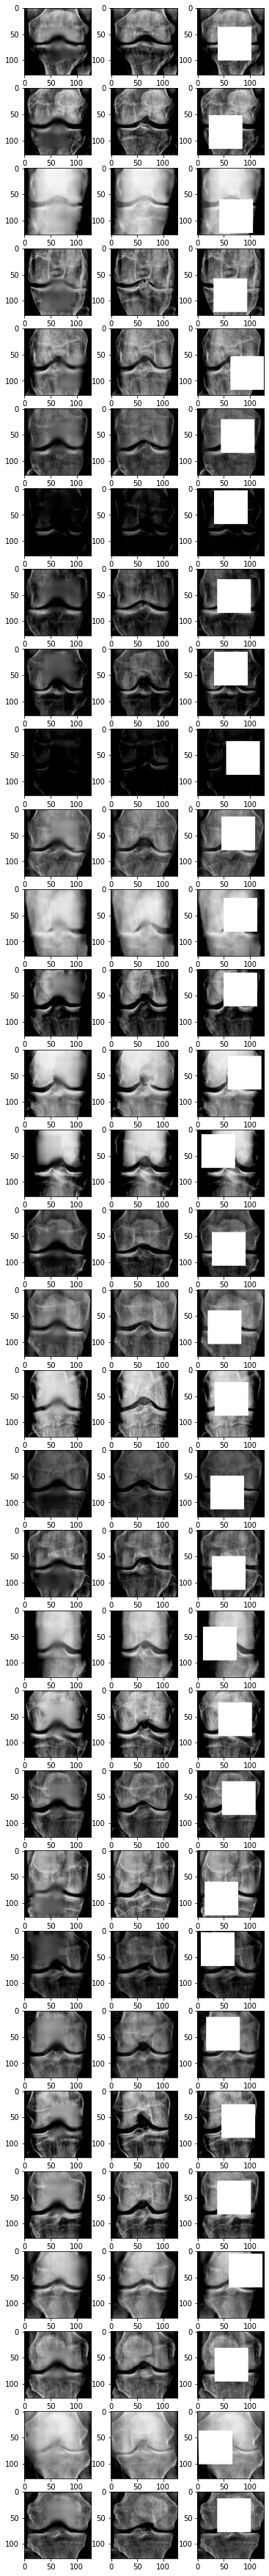

In [18]:
rows = 32
with torch.no_grad():
      fig,axs=plt.subplots(nrows=32,ncols=3,figsize=(6, 2*rows))
      img, masked_img= next(iter(dataloader))
      X=masked_img.to(device)
      pred = model(X)
      for i in range(32):
        p=pred[i]
        p=p.to('cpu')
        p=p.detach()
        p=p.numpy()
        p=p.transpose((1, 2, 0))
        axs[i][0].imshow(p)

        im=img[i]
        im=im.numpy()
        im=im.transpose((1, 2, 0))
        axs[i][1].imshow(im)

        m=masked_img[i]
        m=m.numpy()
        m=m.transpose((1, 2, 0))
        axs[i][2].imshow(m)
        


In [19]:
torch.save(model.state_dict(), "/content/drive/MyDrive/unetlike")